<a href="https://colab.research.google.com/github/Kanika-0905/kanika-codeboosters-2026/blob/main/Day_4_Mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pyspark --quiet

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year,month,to_date,col,round as spark_round
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

spark=SparkSession.builder \
      .appName('Day4_BigData_Sales') \
      .config('spark.sql.adaaptive.enabled','true') \
      .getOrCreate()
print(f'Spark version : {spark.version}')
print(f'SparkSession : ACTIVE')

Spark version : 4.0.2
SparkSession : ACTIVE


In [5]:
df_bronze = spark.read \
     .option('header','true') \
     .option('inferSchema','true') \
     .csv('large_sales_data.csv')
print('===BRONZE LAYER - raw data ===')
print(f'Rows :{df_bronze.count()}')

print(f'Columns : {len(df_bronze.columns)}')
print(f'Columns : {df_bronze.columns}')
print()
df_bronze.printSchema()

===BRONZE LAYER - raw data ===
Rows :5000
Columns : 13
Columns : ['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'revenue', 'order_date', 'city', 'region', 'sales_rep', 'payment_method', 'order_status']

root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)



In [6]:
df_bronze.write \
       .mode('overwrite') \
       .parquet('sales_bronze.parquet')
print('Bronze Parquet saved: sales_bronze.parquet')

import os

def get_dir_size(path):
  if os.path.isfile(path):
    return os.path.getsize(path) / 1024
  total = 0
  for dirpath,dirnames,filenames in os.walk(path):
    for f in filenames:
      total += os.path.getsize(os.path.join(dirpath,f))
  return total/1024
csv_size =get_dir_size('large_sales_data.csv')
parquet_size = get_dir_size('sales_bronze.parquet')
reduction = (1- parquet_size / csv_size)*100

print(f'Csv size : {csv_size:.1f} KB')
print(f'Parquet size : {parquet_size:.1f} KB')
print(f'Reduction : {reduction:.1f}% smaller')
print(f'\nAt 1TB scale: CSV=1000 GB -> Parquet={1000*(1-reduction/100):.0f} GB')

Bronze Parquet saved: sales_bronze.parquet
Csv size : 529.3 KB
Parquet size : 55.1 KB
Reduction : 89.6% smaller

At 1TB scale: CSV=1000 GB -> Parquet=104 GB


In [7]:
df_silver = df_bronze \
.dropDuplicates() \
.dropna(subset=['order_id','product','revenue'])

df_silver=df_silver.withColumn('order_date',to_date(col('order_date'),'dd-MM-yyyy')
)
df_silver=df_silver \
.withColumn('order_year',year(col('order_date'))) \
.withColumn('order_month',month(col('order_date')))

df_silver = df_silver.withColumn( 'revenue_category',F.when(col('revenue')>40000,'High')
.when(col('revenue')>10000,'Medium')
.otherwise('Low'))

print(f'Silver layer rows: {df_silver.count()}')
print('New columns added: order_year, order_month', 'revenue_category')
df_silver.select('product', 'revenue', 'order_year', 'order_month', 'revenue_category').show(8)


Silver layer rows: 5000
New columns added: order_year, order_month revenue_category
+----------+-------+----------+-----------+----------------+
|   product|revenue|order_year|order_month|revenue_category|
+----------+-------+----------+-----------+----------------+
|  Keyboard|  13200|      2023|          2|          Medium|
|    Webcam|  17500|      2023|          1|          Medium|
|   Speaker|  58500|      2023|          4|            High|
|  Keyboard|   9600|      2023|         12|             Low|
|    Laptop| 180000|      2023|          8|            High|
|Headphones|  38500|      2023|          5|          Medium|
|    Webcam|  35000|      2023|         11|          Medium|
|    Laptop| 360000|      2023|          1|            High|
+----------+-------+----------+-----------+----------------+
only showing top 8 rows


In [8]:
df_silver.write \
.mode('overwrite') \
.parquet('sales_silver.parquet')
print('Silver Parquet saved: sales_silver.parquet')
print(f'Silver size : {get_dir_size("sales_silver.parquet"):.1f}KB')
print(f'bronze size : {get_dir_size("sales_bronze.parquet"):.1f}KB')
df_verify = spark.read.parquet('sales_silver.parquet')
print(f'Read-back rows: {df_verify.count()} (Should match  silver count)')
df_verify.printSchema()

Silver Parquet saved: sales_silver.parquet
Silver size : 59.8KB
bronze size : 55.1KB
Read-back rows: 5000 (Should match  silver count)
root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_year: integer (nullable = true)
 |-- order_month: integer (nullable = true)
 |-- revenue_category: string (nullable = true)



In [9]:
import matplotlib.pyplot as plt


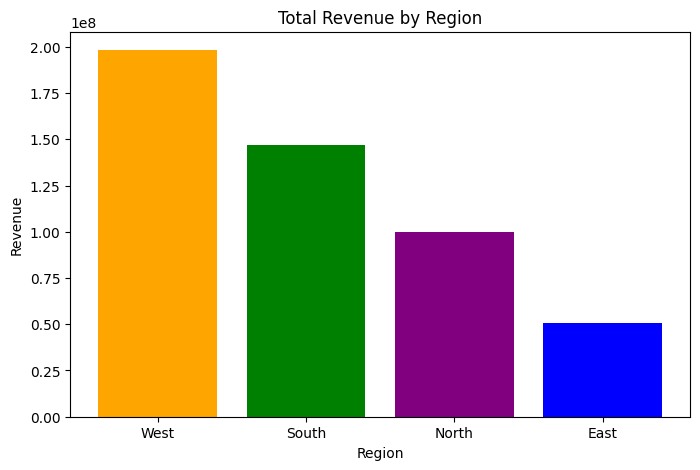

In [10]:
region_revenue = df_silver.groupBy('region') \
    .agg(F.sum('revenue').alias('total_revenue')) \
    .orderBy('region',ascending=False)


region_revenue_pd = region_revenue.toPandas()


plt.figure(figsize=(8, 5))
plt.bar(
    region_revenue_pd['region'],
    region_revenue_pd['total_revenue'],
    color=['orange', 'green', 'purple', 'blue']
)

plt.title("Total Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.show()